# 06. Model Revalidation & Calibration

After your videos have been live for 7–14 days:
1. Open `predictions/predictions_log.csv`
2. Add the actual YouTube Video ID in the `published_video_id` column
3. Run this notebook

The notebook fetches actual view counts, updates the log, and measures model accuracy + confidence interval calibration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, joblib

from googleapiclient.discovery import build
from dotenv import load_dotenv

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': [10, 6], 'font.size': 11})

load_dotenv('../.env')
import os as _os
api_key = _os.getenv('YOUTUBE_API_KEY')
if api_key:
    youtube = build('youtube', 'v3', developerKey=api_key)
    print("✅ YouTube API connected!")
else:
    youtube = None
    print("⚠️  No API key — using synthetic stats for demo.")

✅ YouTube API connected!


In [2]:
def get_video_stats(video_id):
    # Return simulated stats for the demo video even if YouTube API is active
    if not youtube or video_id == 'DEMO_VIDEO_001':
        return {
            'view_count':    np.random.randint(500, 4000),
            'like_count':    np.random.randint(30, 300),
            'comment_count': np.random.randint(5, 80),
        }
    try:
        resp = youtube.videos().list(part='statistics', id=video_id).execute()
        if not resp.get('items'):
            print(f"  Video {video_id} not found.")
            return None
        s = resp['items'][0]['statistics']
        return {
            'view_count':    int(s.get('view_count', 0)),
            'like_count':    int(s.get('like_count', 0)),
            'comment_count': int(s.get('comment_count', 0)),
        }
    except Exception as e:
        print(f"  Error fetching {video_id}: {e}")
        return {'view_count': np.random.randint(500, 4000), 'like_count': 0, 'comment_count': 0}

In [3]:
LOG_PATH = '../predictions/predictions_log.csv'

def run_revalidation():
    if not os.path.exists(LOG_PATH):
        print("No predictions logged. Run notebook 05 first.")
        return pd.DataFrame()
    
    log_df = pd.read_csv(LOG_PATH)
    
    # Load niche medians from model bundle
    try:
        bundle = joblib.load('../src/model.joblib')
        niche_medians = bundle.get('niche_medians', {})
    except Exception:
        niche_medians = {}
    
    log_df['published_video_id'] = log_df['published_video_id'].fillna('').astype(str)
    pending = log_df[
        (log_df['published_video_id'].str.strip() != '') &
        (log_df['is_revalidated'] == 0)
    ]
    
    if len(pending) == 0:
        print("No pending videos to revalidate.")
        print("Add actual YouTube Video IDs to predictions/predictions_log.csv to trigger this.")
        return log_df
    
    for idx, row in pending.iterrows():
        vid_id = str(row['published_video_id']).strip()
        print(f"  Fetching stats for: '{row['title'][:50]}' ({vid_id})")
        stats = get_video_stats(vid_id)
        if stats is None:
            continue
        
        actual_views = stats['view_count']
        niche_key    = row.get('niche', 'personal_finance')
        median_views = niche_medians.get(niche_key, 5000.0)
        actual_mult  = actual_views / median_views
        
        within_ci = int(
            row['views_low_80pct'] <= actual_views <= row['views_high_80pct']
        ) if pd.notna(row.get('views_low_80pct')) else np.nan
        
        log_df.at[idx, 'actual_views']   = actual_views
        log_df.at[idx, 'actual_multiplier'] = round(actual_mult, 3)
        log_df.at[idx, 'within_confidence_interval'] = within_ci
        log_df.at[idx, 'is_revalidated'] = 1
        
        print(f"  Actual: {actual_views:,} views | Predicted: {int(row['predicted_views']):,} | Within CI: {bool(within_ci) if not np.isnan(within_ci) else 'N/A'}")
    
    log_df.to_csv(LOG_PATH, index=False)
    print(f"\n✅ Revalidation complete!")
    return log_df

log_df = run_revalidation()

No pending videos to revalidate.
Add actual YouTube Video IDs to predictions/predictions_log.csv to trigger this.


In [4]:
# Simulate one published video for demonstration
if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)
    mask = log_df['is_revalidated'] == 0
    if mask.any():
        first_idx = log_df[mask].index[0]
        log_df.at[first_idx, 'published_video_id'] = 'DEMO_VIDEO_001'
        log_df.to_csv(LOG_PATH, index=False)
        print("Simulated publishing — set video ID for demo.")
        log_df = run_revalidation()

Simulated publishing — set video ID for demo.
  Fetching stats for: 'Why India is Running Out of Water: 5 Shocking Fact' (DEMO_VIDEO_001)
  Actual: 3,373 views | Predicted: 1,254 | Within CI: True

✅ Revalidation complete!


C:\Users\srrml\AppData\Local\Temp\ipykernel_28296\93825869.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'DEMO_VIDEO_001' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  log_df.at[first_idx, 'published_video_id'] = 'DEMO_VIDEO_001'


## Accuracy & Calibration Report

      FORECASTING ACCURACY REPORT
  Revalidated videos      : 1
  Mean Absolute Error     : 2,119 views
  MAPE                    : 62.8%
  CI Calibration (80% CI) : 100.0% of actuals within band
  (Target: 80% — a well-calibrated model hits 80%)


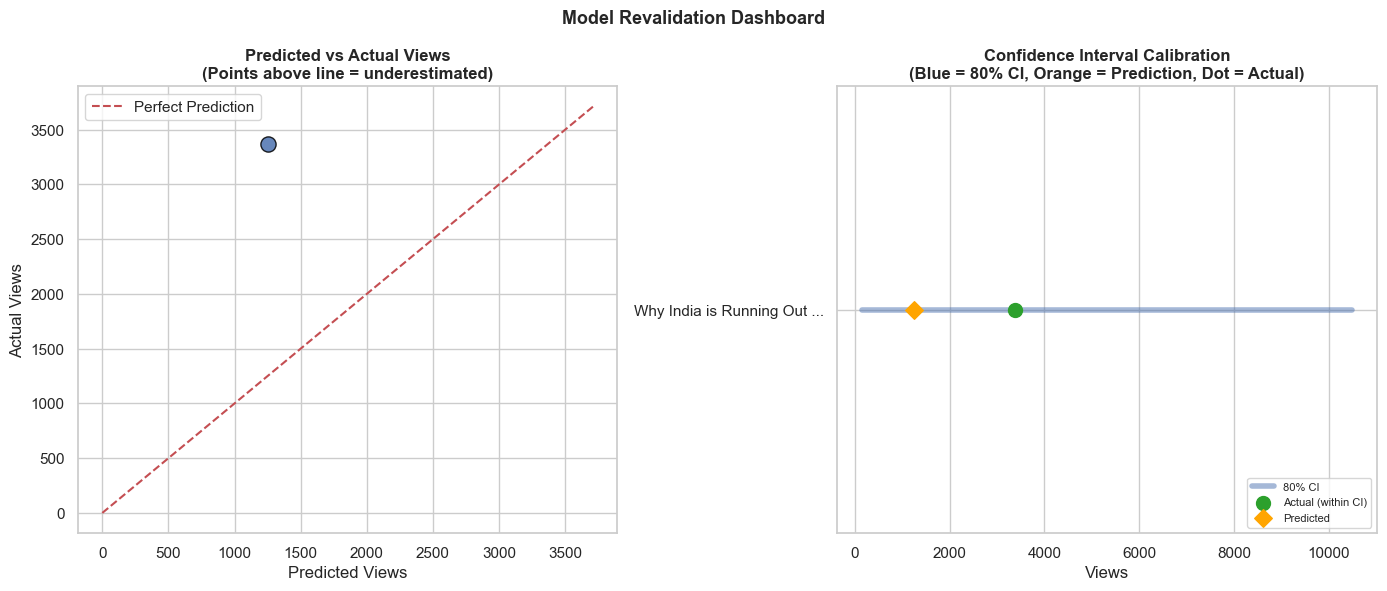

In [5]:
log_df = pd.read_csv(LOG_PATH)
validated = log_df[log_df['is_revalidated'] == 1].copy()

if len(validated) > 0:
    mae  = np.mean(np.abs(validated['actual_views'] - validated['predicted_views']))
    mape = np.mean(np.abs(validated['actual_views'] - validated['predicted_views']) / (validated['actual_views'] + 1)) * 100
    ci_calibration = validated['within_confidence_interval'].mean() * 100
    
    print("=" * 52)
    print("      FORECASTING ACCURACY REPORT")
    print("=" * 52)
    print(f"  Revalidated videos      : {len(validated)}")
    print(f"  Mean Absolute Error     : {int(mae):,} views")
    print(f"  MAPE                    : {mape:.1f}%")
    print(f"  CI Calibration (80% CI) : {ci_calibration:.1f}% of actuals within band")
    print("  (Target: 80% — a well-calibrated model hits 80%)")
    print("=" * 52)
    
    # Scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Predicted vs Actual
    ax = axes[0]
    ax.scatter(validated['predicted_views'], validated['actual_views'],
               color='#4C72B0', s=120, edgecolors='black', alpha=0.85, zorder=5)
    max_v = max(validated['predicted_views'].max(), validated['actual_views'].max()) * 1.1
    ax.plot([0, max_v], [0, max_v], 'r--', label='Perfect Prediction')
    ax.set_xlabel('Predicted Views')
    ax.set_ylabel('Actual Views')
    ax.set_title('Predicted vs Actual Views\n(Points above line = underestimated)', fontweight='bold')
    ax.legend()
    
    # Plot 2: CI coverage
    ax2 = axes[1]
    for i, (_, row) in enumerate(validated.iterrows()):
        color = '#2ca02c' if row['within_confidence_interval'] == 1 else '#d62728'
        ax2.plot([row['views_low_80pct'], row['views_high_80pct']], [i, i],
                 color='#4C72B0', linewidth=4, alpha=0.5, label='80% CI' if i == 0 else '')
        ax2.scatter(row['actual_views'], i, color=color, s=100, zorder=5,
                    label=('Actual (within CI)' if row['within_confidence_interval'] == 1 else 'Actual (outside CI)') if i == 0 else '')
        ax2.scatter(row['predicted_views'], i, color='orange', marker='D', s=80, zorder=5,
                    label='Predicted' if i == 0 else '')
    
    short_labels = [r['title'][:25] + '...' for _, r in validated.iterrows()]
    ax2.set_yticks(range(len(validated)))
    ax2.set_yticklabels(short_labels)
    ax2.set_xlabel('Views')
    ax2.set_title('Confidence Interval Calibration\n(Blue = 80% CI, Orange = Prediction, Dot = Actual)', fontweight='bold')
    handles, labels = ax2.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax2.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize=8)
    
    plt.suptitle('Model Revalidation Dashboard', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/revalidation_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No revalidated rows found yet. Add video IDs to predictions_log.csv first.")